In [8]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.enums import ColorInterp
import matplotlib.pyplot as plt
from rasterio.plot import show

# -------------------------
# USER INPUTS
# -------------------------
TILE1_TIF = "/home/user/data_shared/T16TEK/20220107T163649.tif"
TILE2_TIF = "/home/user/data_shared/T16TFK/20220107T163649.tif"
BAND = 2  # for single-band GeoTIFFs

# -------------------------
# LOAD + ALIGN
# -------------------------
s1 = rasterio.open(TILE1_TIF) 
# a1 = s1.read(BAND)

s2 = rasterio.open(TILE2_TIF)
# a2 = s2.read(BAND)
    


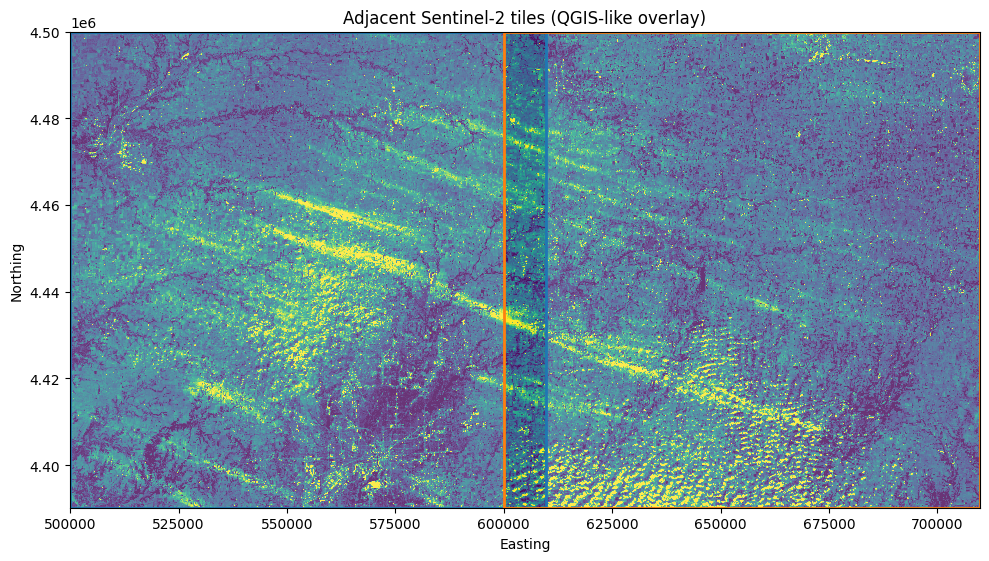

In [15]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def read_masked(src, band=1):
    a = src.read(band).astype("float32")
    # mask nodata
    if src.nodata is not None:
        a[a == src.nodata] = np.nan
    return a

tile1_path = TILE1_TIF
tile2_path = TILE2_TIF

with rasterio.open(tile1_path) as s1, rasterio.open(tile2_path) as s2:
    if s1.crs != s2.crs:
        raise ValueError(f"CRS differ: tile1={s1.crs}, tile2={s2.crs}. QGIS reprojects on-the-fly; matplotlib won't.")

    a1 = read_masked(s1, 1)
    a2 = read_masked(s2, 1)

    e1 = (s1.bounds.left, s1.bounds.right, s1.bounds.bottom, s1.bounds.top)
    e2 = (s2.bounds.left, s2.bounds.right, s2.bounds.bottom, s2.bounds.top)

# shared contrast stretch like QGIS (percent clip)
vals = np.concatenate([a1[np.isfinite(a1)].ravel(), a2[np.isfinite(a2)].ravel()])
vmin, vmax = np.percentile(vals, (2, 98))

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(a1, extent=e1, origin="upper", vmin=vmin, vmax=vmax, interpolation="nearest", alpha=0.8)
ax.imshow(a2, extent=e2, origin="upper", vmin=vmin, vmax=vmax, interpolation="nearest", alpha=0.8)

# draw footprints (helps sanity-check overlap)
ax.plot([e1[0], e1[1], e1[1], e1[0], e1[0]], [e1[2], e1[2], e1[3], e1[3], e1[2]], linewidth=2)
ax.plot([e2[0], e2[1], e2[1], e2[0], e2[0]], [e2[2], e2[2], e2[3], e2[3], e2[2]], linewidth=2)

ax.set_aspect("equal")
ax.set_title("Adjacent Sentinel-2 tiles (QGIS-like overlay)")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
from rasterio.coords import BoundingBox
TILE1_TIF = "/home/user/data_shared/T32UPU/20220615T101559.tif"
TILE2_TIF = "/home/user/data_shared/T32UQU/20220212T101029.tif"

def snap_bounds(bounds, res):
    """Snap bounds to a multiple of res so pixels line up cleanly."""
    left   = np.floor(bounds.left  / res) * res
    bottom = np.floor(bounds.bottom/ res) * res
    right  = np.ceil (bounds.right / res) * res
    top    = np.ceil (bounds.top   / res) * res
    return BoundingBox(left, bottom, right, top)

def intersect_bounds(b1, b2):
    left   = max(b1.left,   b2.left)
    bottom = max(b1.bottom, b2.bottom)
    right  = min(b1.right,  b2.right)
    top    = min(b1.top,    b2.top)
    if (right <= left) or (top <= bottom):
        return None
    return BoundingBox(left, bottom, right, top)

def mask_from_reproject(src, dst_shape, dst_transform, dst_crs, band=1):
    dst = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=rasterio.band(src, band),
        destination=dst,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=np.nan,
        resampling=Resampling.nearest,
    )
    return np.isfinite(dst)

# -------------------------
# USER INPUTS
# -------------------------
# tile1_path = "/path/to/tile1.tif"
# tile2_path = "/path/to/tile2.tif"
band = 1
target_res = 10.0  # meters per pixel for 10m S2 bands

with rasterio.open(TILE1_TIF) as s1, rasterio.open(TILE2_TIF) as s2:
    if s1.crs != s2.crs:
        raise ValueError("CRS differ. Reproject one tile to the other CRS first (or tell me and I’ll adapt the code).")

    # Overlap in map coordinates
    ov = intersect_bounds(s1.bounds, s2.bounds)
    if ov is None:
        print("No spatial overlap between these rasters.")
        raise SystemExit

    # Snap overlap bounds to target_res grid
    ov = snap_bounds(ov, target_res)

    # Build a common transform/grid for the overlap area
    width  = int(round((ov.right - ov.left) / target_res))
    height = int(round((ov.top - ov.bottom) / target_res))
    transform = from_origin(ov.left, ov.top, target_res, target_res)

    # Reproject both into that overlap grid and build masks
    m1 = mask_from_reproject(s1, (height, width), transform, s1.crs, band=band)
    m2 = mask_from_reproject(s2, (height, width), transform, s1.crs, band=band)

# Count overlap pixels
overlap_pixels = int(np.count_nonzero(m1 & m2))
overlap_area_m2 = overlap_pixels * (target_res * target_res)

print("Overlap grid size (px):", width, "x", height)
print("Overlapping valid pixels:", overlap_pixels)
print("Overlap area (m^2):", overlap_area_m2)
print("Overlap area (km^2):", overlap_area_m2 / 1e6)


Overlap grid size (px): 984 x 10980
Overlapping valid pixels: 10804320
Overlap area (m^2): 1080432000.0
Overlap area (km^2): 1080.432
